# Notebook 2 — data overview

Providing a descriptive overview of the cleaned panel dataset: sample composition, sector structure, regional distribution, and frontline region dynamics.

**Steps performed:**
1. Loading cleaned data and configuring chart style
2. Sample overview: observations, firms, years
3. Firm status and age distributions
4. Sector structure: KVED counts, revenue and firm shares
5. Top-5 sector dynamics: absolute revenue and share over time
6. Regional analysis: revenue, top sectors, top KVEDs
7. Frontline region analysis: classification, dynamics, choropleth map

**Input:** `df_cleaned.csv` from Notebook 1.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from matplotlib.colorbar import ColorbarBase
import seaborn as sns

## 1. Loading data and configuring chart style

Reading the cleaned dataset and setting thesis-wide chart parameters — applied once, inherited by all subsequent plots.

In [2]:
df = pd.read_csv('df_cleaned.csv', sep=';', encoding='utf-8', low_memory=False)
print('Dataset shape:', df.shape)

Dataset shape: (81062, 167)


In [3]:
# Global chart style
plt.style.use('seaborn-v0_8-whitegrid')

mpl.rcParams.update({
    'figure.facecolor':  'white',
    'figure.dpi':        150,
    'font.family':       'serif',
    'font.serif':        ['Georgia', 'Times New Roman', 'DejaVu Serif'],
    'font.size':         11,
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#2c2c2c',
    'axes.linewidth':    0.8,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     14,
    'axes.labelsize':    11,
    'axes.labelcolor':   '#2c2c2c',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'grid.color':        '#e0e0e0',
    'grid.linewidth':    0.6,
    'grid.linestyle':    '--',
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'xtick.color':       '#2c2c2c',
    'ytick.color':       '#2c2c2c',
    'legend.fontsize':   10,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  '#cccccc',
    'lines.linewidth':   2,
    'lines.markersize':  7,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

COLORS = {
    'primary':   '#2c5f8a',
    'secondary': '#4a9aba',
    'positive':  '#3ab5a5',
    'negative':  '#d9534f',
    'neutral':   '#95a5a6',
    'accent':    '#f0c060',
    'light':     '#ddeef7',
}

COLOR_SEQ = [
    COLORS['primary'], COLORS['secondary'], COLORS['positive'],
    COLORS['negative'], COLORS['accent'], COLORS['neutral'],
]

print('Chart style configured')
print('   Font    : Georgia (serif)')
print('   Palette : Navy / Steel Blue / Teal / Red / Gold')

Chart style configured
   Font    : Georgia (serif)
   Palette : Navy / Steel Blue / Teal / Red / Gold


In [4]:
# Lookup tables used across multiple sections
SECTOR_MAP = {
    'A': 'Agriculture',           'B': 'Mining',
    'C': 'Manufacturing',         'D': 'Energy',
    'E': 'Water & Waste',         'F': 'Construction',
    'G': 'Wholesale & Retail Trade', 'H': 'Transportation',
    'I': 'Accommodation & Food',  'J': 'Information & Communication',
    'K': 'Financial Services',    'L': 'Real Estate',
    'M': 'Professional Services', 'N': 'Administrative Services',
    'O': 'Public Administration', 'P': 'Education',
    'Q': 'Health & Social Work',  'R': 'Arts & Entertainment',
    'S': 'Other Services',
}

TOP5_SECTORS = ['Wholesale & Retail Trade', 'Manufacturing',
                'Energy', 'Agriculture', 'Mining']


FRONTLINE_2014 = ['Донецька область', 'Луганська область']
FRONTLINE_2022 = ['Харківська область', 'Запорізька область',
                  'Херсонська область', 'Миколаївська область',
                  'Чернігівська область', 'Сумська область']

REGION_UA_TO_EN = {
    'Донецька область':     'Donetsk Oblast',
    'Луганська область':    'Luhansk Oblast',
    'Харківська область':   'Kharkiv Oblast',
    'Запорізька область':   'Zaporizhzhia Oblast',
    'Херсонська область':   'Kherson Oblast',
    'Миколаївська область': 'Mykolaiv Oblast',
    'Чернігівська область': 'Chernihiv Oblast',
    'Сумська область':      'Sumy Oblast',
}

# Matches GADM shapefile NAME_1 values
REGION_SHAPEFILE_MAP = {
    'м. Київ':                   'KievCity',
    'Дніпропетровська область':  "Dnipropetrovs'k",
    'Київська область':          'Kiev',
    'Львівська область':         "L'viv",
    'Харківська область':        'Kharkiv',
    'Одеська область':           'Odessa',
    'Полтавська область':        'Poltava',
    'Черкаська область':         'Cherkasy',
    'Вінницька область':         'Vinnytsya',
    'Волинська область':         'Volyn',
    'Запорізька область':        'Zaporizhia',
    'Кіровоградська область':    'Kirovohrad',
    'Миколаївська область':      'Mykolayiv',
    'Донецька область':          "Donets'k",
    'Закарпатська область':      'Zakarpattia',
    'Рівненська область':        'Rivne',
    'Чернігівська область':      'Chernihiv',
    'Тернопільська область':     "Ternopil'",
    'Сумська область':           'Sumy',
    'Житомирська область':       'Zhytomyr',
    'Хмельницька область':       "Khmel'nyts'kyy",
    'Івано-Франківська область': "Ivano-Frankivs'k",
    'Чернівецька область':       'Chernivtsi',
    'Херсонська область':        'Kherson',
    'Луганська область':         "Luhans'k",
}

STATUS_MAP = {
    'Не перебуває в процесі припинення':        'Active',
    'В стані припинення':                        'In Liquidation',
    'Припинено':                                 'Terminated',
    'Порушено справу про банкрутство (санація)': 'Bankruptcy (Restructuring)',
    'Порушено справу про банкрутство':           'Bankruptcy',
}

YEARS = sorted(df['Year'].dropna().astype(int).unique())

In [5]:
# Helper: add COVID / Full-Scale War shading to an axis
def add_crisis_bands(ax, y_max):
    ax.axvspan(2019.6, 2020.4, alpha=0.10, color=COLORS['accent'],   zorder=2)
    ax.axvspan(2021.6, 2022.4, alpha=0.10, color=COLORS['negative'], zorder=2)
    ax.text(2020, y_max * 0.98, 'COVID-19',
            ha='center', fontsize=8.5, color='#8a6500',
            fontweight='bold', style='italic', va='top')
    ax.text(2022, y_max * 0.98, 'Full-Scale War',
            ha='center', fontsize=8.5, color=COLORS['negative'],
            fontweight='bold', style='italic', va='top')

## 2. Sample overview

Printing top-level panel statistics: total observations, unique firms, year coverage, and firm count per year.

In [6]:
print('SAMPLE OVERVIEW')
print(f"\nTotal observations  : {len(df):,}")
print(f"Total unique firms  : {df['Firm ID'].nunique():,}")
print(f"Years covered       : {int(df['Year'].min())} - {int(df['Year'].max())}")

firms_per_year = (
    df.groupby('Year')['Firm ID'].nunique()
    .reset_index()
    .rename(columns={'Firm ID': 'Unique Firms'})
)
firms_per_year['Year'] = firms_per_year['Year'].astype(int)

print('\nUnique firms per year:')
print(firms_per_year.to_string(index=False))

SAMPLE OVERVIEW

Total observations  : 81,062
Total unique firms  : 18,119
Years covered       : 2018 - 2024

Unique firms per year:
 Year  Unique Firms
 2018         10888
 2019         12493
 2020         10651
 2021         12603
 2022         12086
 2023         11867
 2024         10474


In [7]:
# Distribution of firms by number of available financial statements
obs_per_firm = (
    df.groupby('Firm ID')['Year'].count()
    .reset_index()
    .rename(columns={'Year': 'Num Years'})
)

year_counts = obs_per_firm['Num Years'].value_counts().sort_index()
table = year_counts.reset_index()
table.columns = ['Number of Financial Statements', 'Number of Firms']
table = table[table['Number of Financial Statements'].between(2, 7)]
print(table.to_string(index=False))

 Number of Financial Statements  Number of Firms
                              2             3921
                              3             2575
                              4             2829
                              5             2179
                              6             3021
                              7             3594


## 3. Firm status distribution

Translating Ukrainian status labels to English and summarising unique firm counts by status.

In [8]:
df['Firm Status EN'] = df['Firm Status'].map(STATUS_MAP)

status_table = (
    df.groupby('Firm Status EN')['Firm ID']
    .nunique()
    .reset_index()
    .rename(columns={'Firm ID': 'Unique Firms'})
)
status_table['Share (%)'] = (
    status_table['Unique Firms'] / status_table['Unique Firms'].sum() * 100
).round(1)
status_table = status_table.sort_values('Unique Firms', ascending=False)

print('Firm status distribution (unique firms)')
print(status_table.to_string(index=False))

Firm status distribution (unique firms)
            Firm Status EN  Unique Firms  Share (%)
                    Active         16437       90.7
            In Liquidation           795        4.4
                Terminated           727        4.0
                Bankruptcy           125        0.7
Bankruptcy (Restructuring)            35        0.2


## 4. Firm age distribution

Computing mean age per firm across all available years and plotting a histogram with 2-year bins. Firms with average age above 30 years are excluded from the chart for readability.

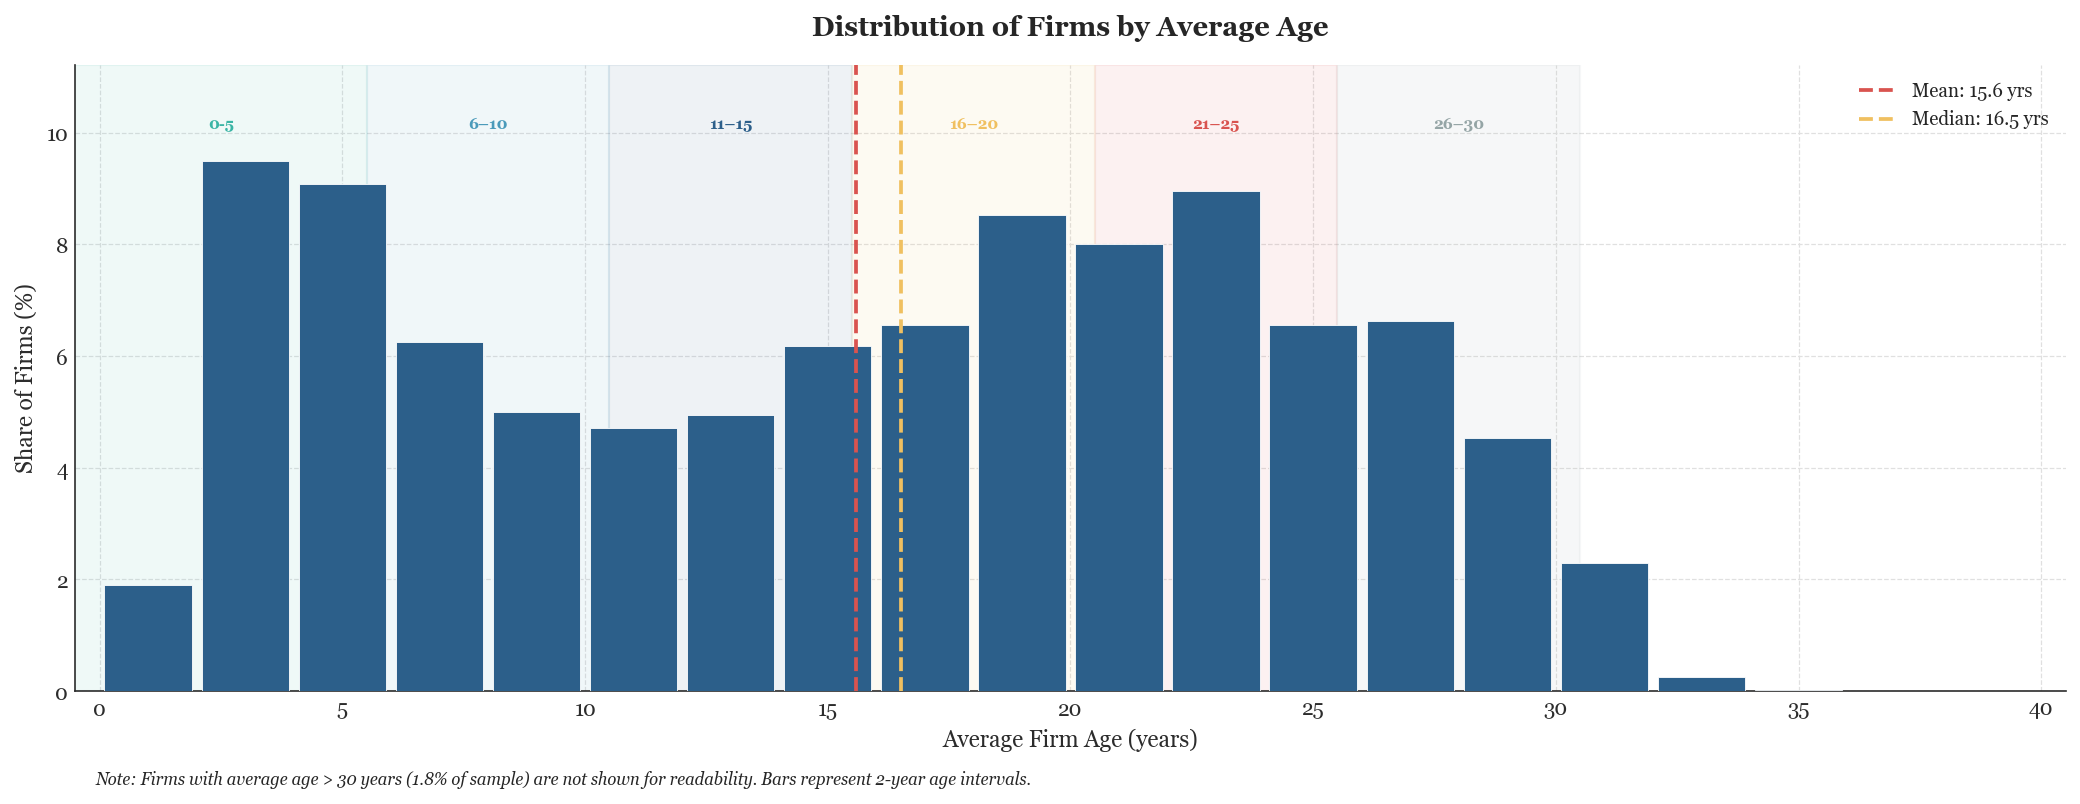

In [9]:
firm_age_avg = (
    df[df['Firm Age'].notna() & (df['Firm Age'] >= 0)]
    .groupby('Firm ID')['Firm Age']
    .mean()
    .reset_index()
    .rename(columns={'Firm Age': 'Avg Age'})
)

total_firms  = len(firm_age_avg)
share_30plus = (firm_age_avg['Avg Age'] > 30).sum() / total_firms * 100
mean_age     = firm_age_avg['Avg Age'].mean()
median_age   = firm_age_avg['Avg Age'].median()

age_values   = firm_age_avg[firm_age_avg['Avg Age'] <= 40]['Avg Age'].values
counts, bin_edges = np.histogram(age_values, bins=np.arange(0, 41, 2))
shares       = counts / total_firms * 100
bin_centers  = (bin_edges[:-1] + bin_edges[1:]) / 2
max_share    = shares.max()

age_bands = [
    (0,   5,  COLORS['positive'],  '0-5'),
    (6,  10,  COLORS['secondary'], '6–10'),
    (11, 15,  COLORS['primary'],   '11–15'),
    (16, 20,  COLORS['accent'],    '16–20'),
    (21, 25,  COLORS['negative'],  '21–25'),
    (26, 30,  COLORS['neutral'],   '26–30'),
]

fig, ax = plt.subplots(figsize=(14, 5.5))

for x_start, x_end, color, label in age_bands:
    ax.axvspan(x_start - 0.5, x_end + 0.5, alpha=0.08, color=color, zorder=1)
    ax.text((x_start + x_end) / 2, max_share * 1.06, label,
            ha='center', fontsize=7.5, color=color, fontweight='bold')

ax.bar(bin_centers, shares, color=COLORS['primary'],
       edgecolor='white', linewidth=0.4, width=1.8, zorder=3)

ax.axvline(mean_age,   color=COLORS['negative'], linewidth=1.8,
           linestyle='--', zorder=4, label=f'Mean: {mean_age:.1f} yrs')
ax.axvline(median_age, color=COLORS['accent'],   linewidth=1.8,
           linestyle='--', zorder=4, label=f'Median: {median_age:.1f} yrs')

ax.set_title('Distribution of Firms by Average Age', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Firm Age (years)')
ax.set_ylabel('Share of Firms (%)')
ax.set_xlim(-0.5, 40.5)
ax.set_xticks(range(0, 41, 5))
ax.set_ylim(0, max_share * 1.18)
ax.legend(fontsize=9)
ax.text(0.01, -0.15,
        f"Note: Firms with average age > 30 years ({share_30plus:.1f}% of sample) "
        f"are not shown for readability. Bars represent 2-year age intervals.",
        transform=ax.transAxes, fontsize=8, style='italic')

plt.tight_layout()
plt.savefig('firm_age_distribution.png')
plt.show()

## 5. Sector structure

Counting unique KVEDs and firms per sector (NACE division), then plotting paired horizontal bars showing revenue and firm shares — for the full 2018–2024 period and for 2024 separately.

In [10]:
print(f"Total unique KVEDs  : {df['KVED'].nunique():,}")
print(f"Total unique Sectors: {df['Sector'].nunique():,}")

sector_kved  = df.groupby('Sector')['KVED'].nunique().reset_index().rename(columns={'KVED': 'Unique KVEDs'})
sector_firms = df.groupby('Sector')['Firm ID'].nunique().reset_index().rename(columns={'Firm ID': 'Unique Firms'})
sector_rev   = df.groupby('Sector')['Net Revenue'].sum().reset_index().rename(columns={'Net Revenue': 'Total Revenue'})

sector_data = (
    sector_kved
    .merge(sector_firms, on='Sector')
    .merge(sector_rev,   on='Sector')
)
sector_data['Sector Label']      = sector_data['Sector'].map(SECTOR_MAP)
sector_data['Revenue Share (%)'] = (sector_data['Total Revenue'] / sector_data['Total Revenue'].sum() * 100).round(1)
sector_data['Firms Share (%)']   = (sector_data['Unique Firms']  / sector_data['Unique Firms'].sum()  * 100).round(1)
sector_data = sector_data.sort_values('Revenue Share (%)', ascending=False)

print('\nKVEDs and firms per sector:')
print(sector_data[['Sector', 'Sector Label', 'Unique KVEDs',
                   'Unique Firms', 'Firms Share (%)', 'Revenue Share (%)']]
      .to_string(index=False))

Total unique KVEDs  : 542
Total unique Sectors: 19

KVEDs and firms per sector:
Sector                Sector Label  Unique KVEDs  Unique Firms  Firms Share (%)  Revenue Share (%)
     G    Wholesale & Retail Trade            85          2901             16.0               41.5
     C               Manufacturing           208          2957             16.3               19.6
     D                      Energy             8           442              2.4                9.8
     A                 Agriculture            28          2854             15.8                7.4
     B                      Mining            15           476              2.6                4.3
     H              Transportation            17           735              4.1                3.4
     M       Professional Services            19           754              4.2                2.4
     F                Construction            20           754              4.2                2.2
     J Information & Communic

In [11]:
TOP5_COLORS = {
    'Wholesale & Retail Trade': COLORS['primary'],
    'Manufacturing':  COLORS['positive'],
    'Energy': COLORS['accent'],
    'Agriculture': COLORS['negative'],
    'Mining': COLORS['secondary'],
}

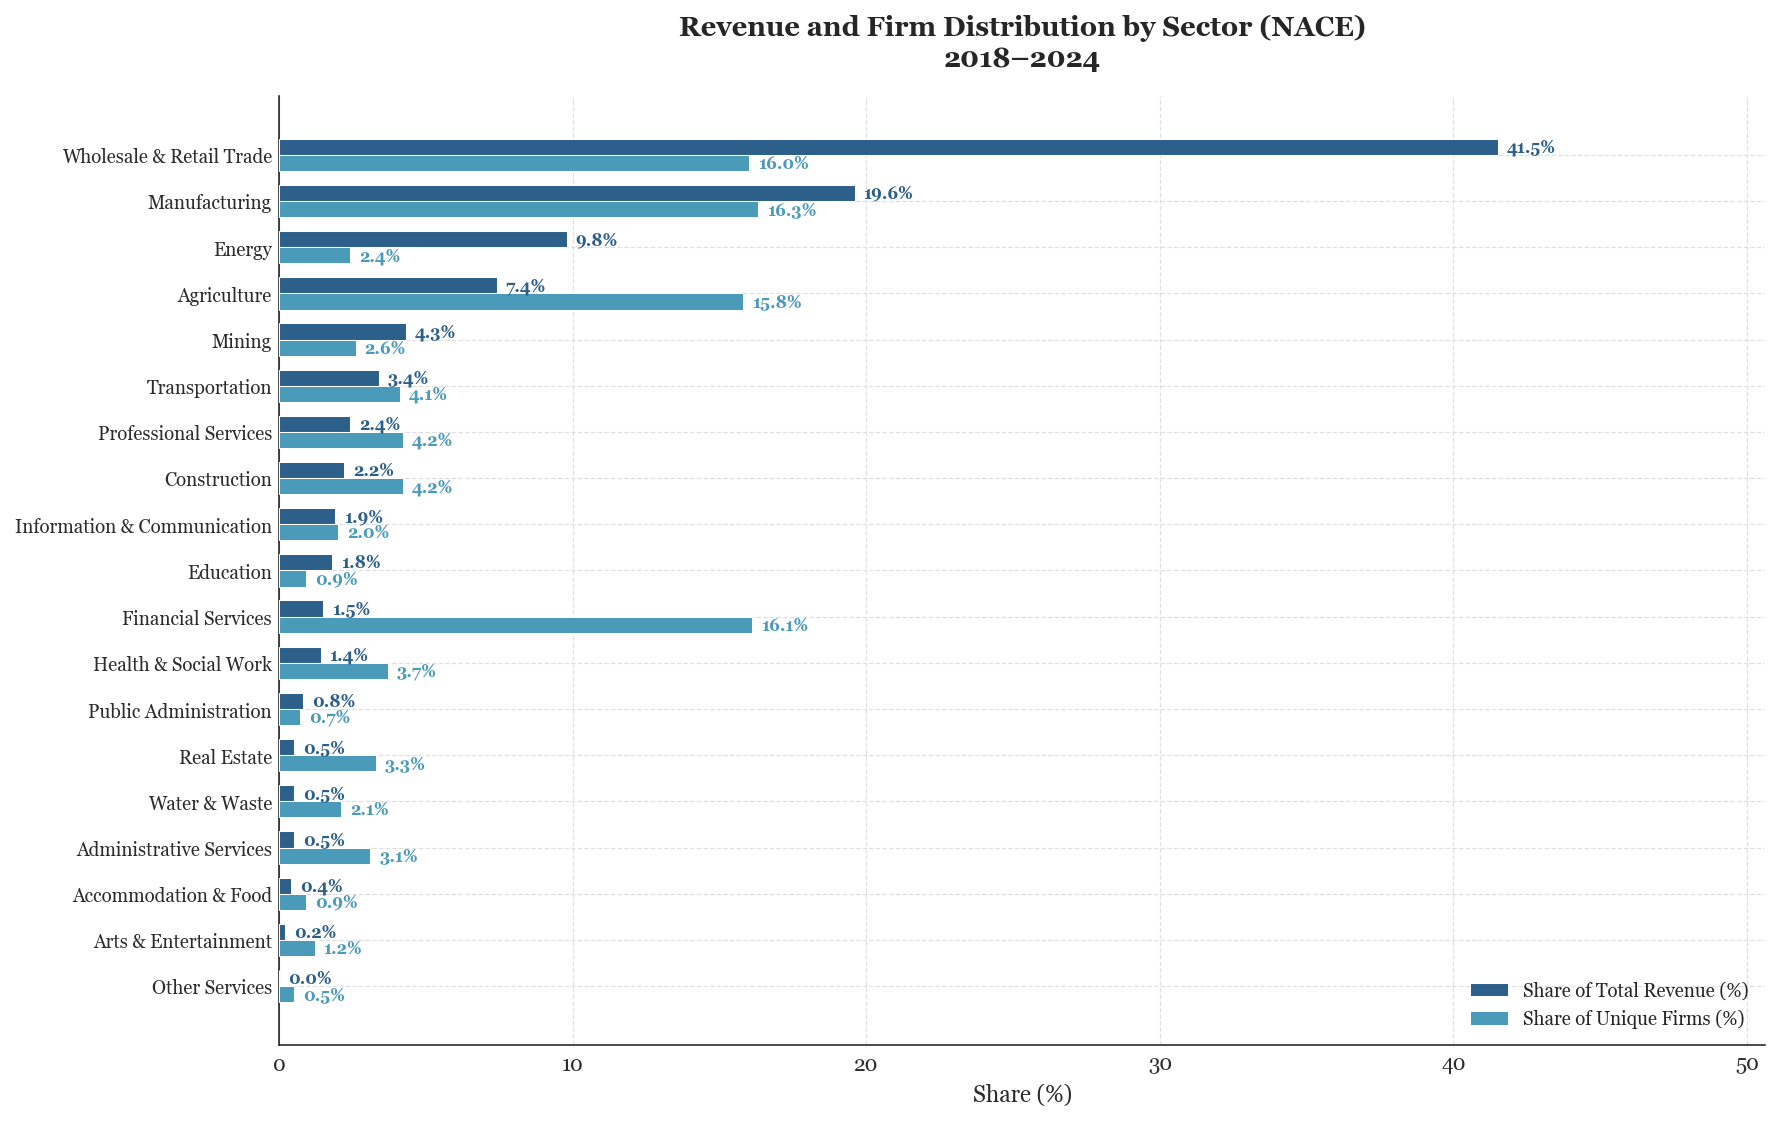

In [12]:
# Helper: draw paired horizontal bar chart (revenue share vs firm share)
def plot_sector_bars(data, title, filename):
    fig, ax = plt.subplots(figsize=(12, 8))
    bar_height = 0.35
    y_pos      = range(len(data))

    bars_rev = ax.barh(
        [y - bar_height / 2 for y in y_pos],
        data['Revenue Share (%)'],
        height=bar_height, color=COLORS['primary'],
        edgecolor='white', linewidth=0.5,
        label='Share of Total Revenue (%)', zorder=3
    )
    bars_firms = ax.barh(
        [y + bar_height / 2 for y in y_pos],
        data['Firms Share (%)'],
        height=bar_height, color=COLORS['secondary'],
        edgecolor='white', linewidth=0.5,
        label='Share of Unique Firms (%)', zorder=3
    )

    for bar, val in zip(bars_rev, data['Revenue Share (%)']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=8,
                color=COLORS['primary'], fontweight='bold')
    for bar, val in zip(bars_firms, data['Firms Share (%)']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=8,
                color=COLORS['secondary'], fontweight='bold')

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(data['Sector Label'], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Share (%)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlim(0, max(data['Revenue Share (%)'].max(),
                       data['Firms Share (%)'].max()) * 1.22)
    ax.legend(fontsize=9, loc='lower right')
    ax.axvline(x=0, color='grey', linewidth=0.5)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)
    plt.savefig(filename)
    plt.show()


# 2018–2024
plot_sector_bars(
    sector_data,
    'Revenue and Firm Distribution by Sector (NACE)\n2018–2024',
    'sector_revenue_firms_share.png'
)

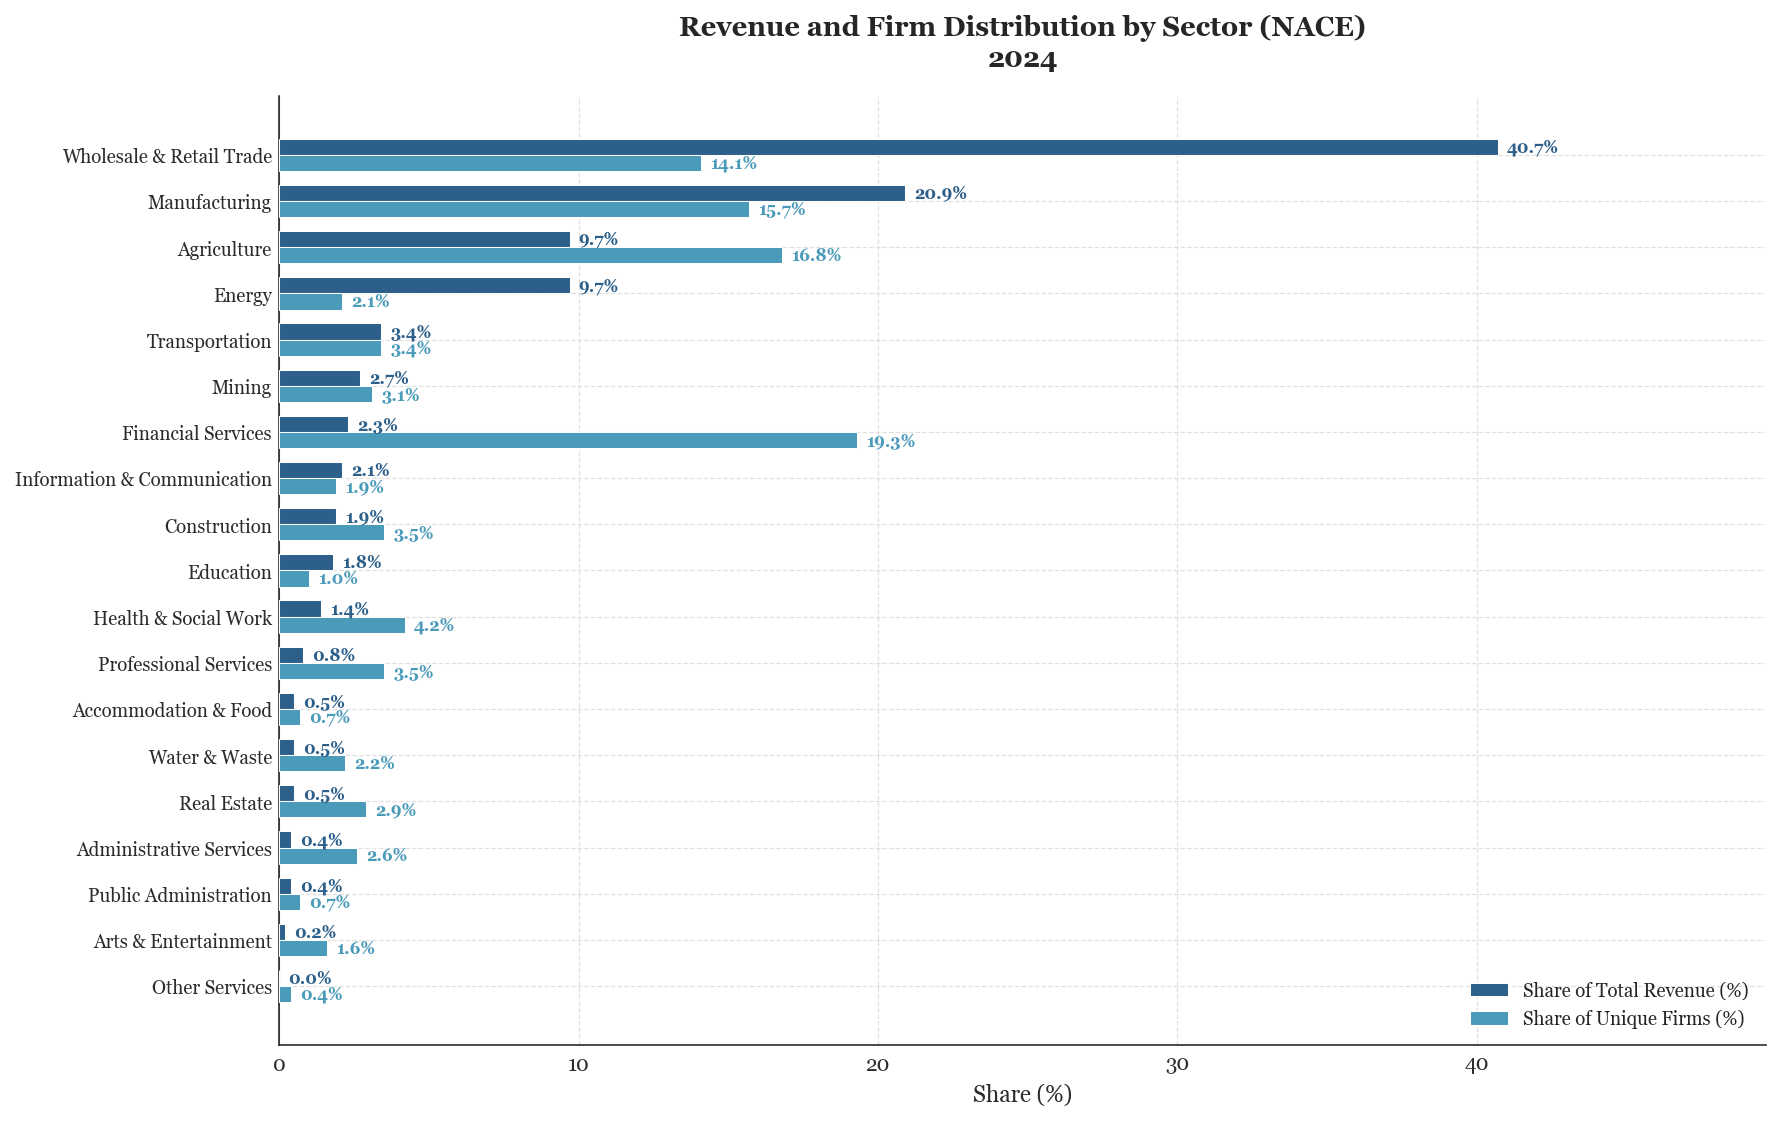

In [13]:
# Same chart for 2024 only
df_2024 = df[df['Year'] == 2024].copy()

sector_rev_2024   = df_2024.groupby('Sector')['Net Revenue'].sum().reset_index().rename(columns={'Net Revenue': 'Total Revenue'})
sector_firms_2024 = df_2024.groupby('Sector')['Firm ID'].nunique().reset_index().rename(columns={'Firm ID': 'Unique Firms'})

sector_data_2024 = sector_rev_2024.merge(sector_firms_2024, on='Sector')
sector_data_2024['Sector Label']      = sector_data_2024['Sector'].map(SECTOR_MAP)
sector_data_2024['Revenue Share (%)'] = (sector_data_2024['Total Revenue'] / sector_data_2024['Total Revenue'].sum() * 100).round(1)
sector_data_2024['Firms Share (%)']   = (sector_data_2024['Unique Firms']  / sector_data_2024['Unique Firms'].sum()  * 100).round(1)
sector_data_2024 = sector_data_2024.sort_values('Revenue Share (%)', ascending=False)

plot_sector_bars(
    sector_data_2024,
    'Revenue and Firm Distribution by Sector (NACE)\n2024',
    'sector_revenue_firms_share_2024.png'
)

## 6. Top-5 sector dynamics

Building revenue and firm time series by sector, then plotting two pairs of line charts: absolute values (bn UAH / firm count) and annual shares (%).

In [14]:
# Revenue by sector and year — with annual shares
revenue_by_sector_year = (
    df.groupby(['Year', 'Sector'])['Net Revenue']
    .sum().reset_index()
    .rename(columns={'Net Revenue': 'Total Net Revenue'})
)
revenue_by_sector_year['Sector Label'] = revenue_by_sector_year['Sector'].map(SECTOR_MAP)
revenue_by_sector_year['Year']         = revenue_by_sector_year['Year'].astype(int)

total_rev_by_year = (
    revenue_by_sector_year.groupby('Year')['Total Net Revenue']
    .sum().reset_index()
    .rename(columns={'Total Net Revenue': 'Total Rev Year'})
)
revenue_by_sector_year = revenue_by_sector_year.merge(total_rev_by_year, on='Year')
revenue_by_sector_year['Revenue Share (%)'] = (
    revenue_by_sector_year['Total Net Revenue'] /
    revenue_by_sector_year['Total Rev Year'] * 100
)
print(f'revenue_by_sector_year: {revenue_by_sector_year.shape}')

revenue_by_sector_year: (133, 6)


In [15]:
# Firms by sector and year — with annual shares
firms_by_sector_year = (
    df.groupby(['Year', 'Sector'])['Firm ID']
    .nunique().reset_index()
    .rename(columns={'Firm ID': 'Unique Firms'})
)
firms_by_sector_year['Sector Label'] = firms_by_sector_year['Sector'].map(SECTOR_MAP)
firms_by_sector_year['Year']         = firms_by_sector_year['Year'].astype(int)

total_firms_by_year = (
    firms_by_sector_year.groupby('Year')['Unique Firms']
    .sum().reset_index()
    .rename(columns={'Unique Firms': 'Total Firms Year'})
)
firms_by_sector_year = firms_by_sector_year.merge(total_firms_by_year, on='Year')
firms_by_sector_year['Firms Share (%)'] = (
    firms_by_sector_year['Unique Firms'] /
    firms_by_sector_year['Total Firms Year'] * 100
)
print(f'firms_by_sector_year: {firms_by_sector_year.shape}')

firms_by_sector_year: (133, 6)


In [16]:
# Aggregate non-top-5 sectors into "Other" — revenue
revenue_other = (
    revenue_by_sector_year[~revenue_by_sector_year['Sector Label'].isin(TOP5_SECTORS)]
    .groupby('Year').agg(
        Total_Net_Revenue = ('Total Net Revenue', 'sum'),
        Total_Rev_Year    = ('Total Rev Year',    'first')
    ).reset_index()
    .rename(columns={'Total_Net_Revenue': 'Total Net Revenue'})
)
revenue_other['Revenue Share (%)'] = (
    revenue_other['Total Net Revenue'] / revenue_other['Total_Rev_Year'] * 100
)
revenue_other['Sector Label'] = 'Other'
print(f'revenue_other: {revenue_other.shape}')

revenue_other: (7, 5)


In [17]:
# Aggregate non-top-5 sectors into "Other" — firms
firms_other = (
    firms_by_sector_year[~firms_by_sector_year['Sector Label'].isin(TOP5_SECTORS)]
    .groupby('Year').agg(
        Unique_Firms     = ('Unique Firms',     'sum'),
        Total_Firms_Year = ('Total Firms Year', 'first')
    ).reset_index()
    .rename(columns={'Unique_Firms': 'Unique Firms'})
)
firms_other['Firms Share (%)'] = (
    firms_other['Unique Firms'] / firms_other['Total_Firms_Year'] * 100
)
firms_other['Sector Label'] = 'Other'
print(f'firms_other: {firms_other.shape}')

firms_other: (7, 5)


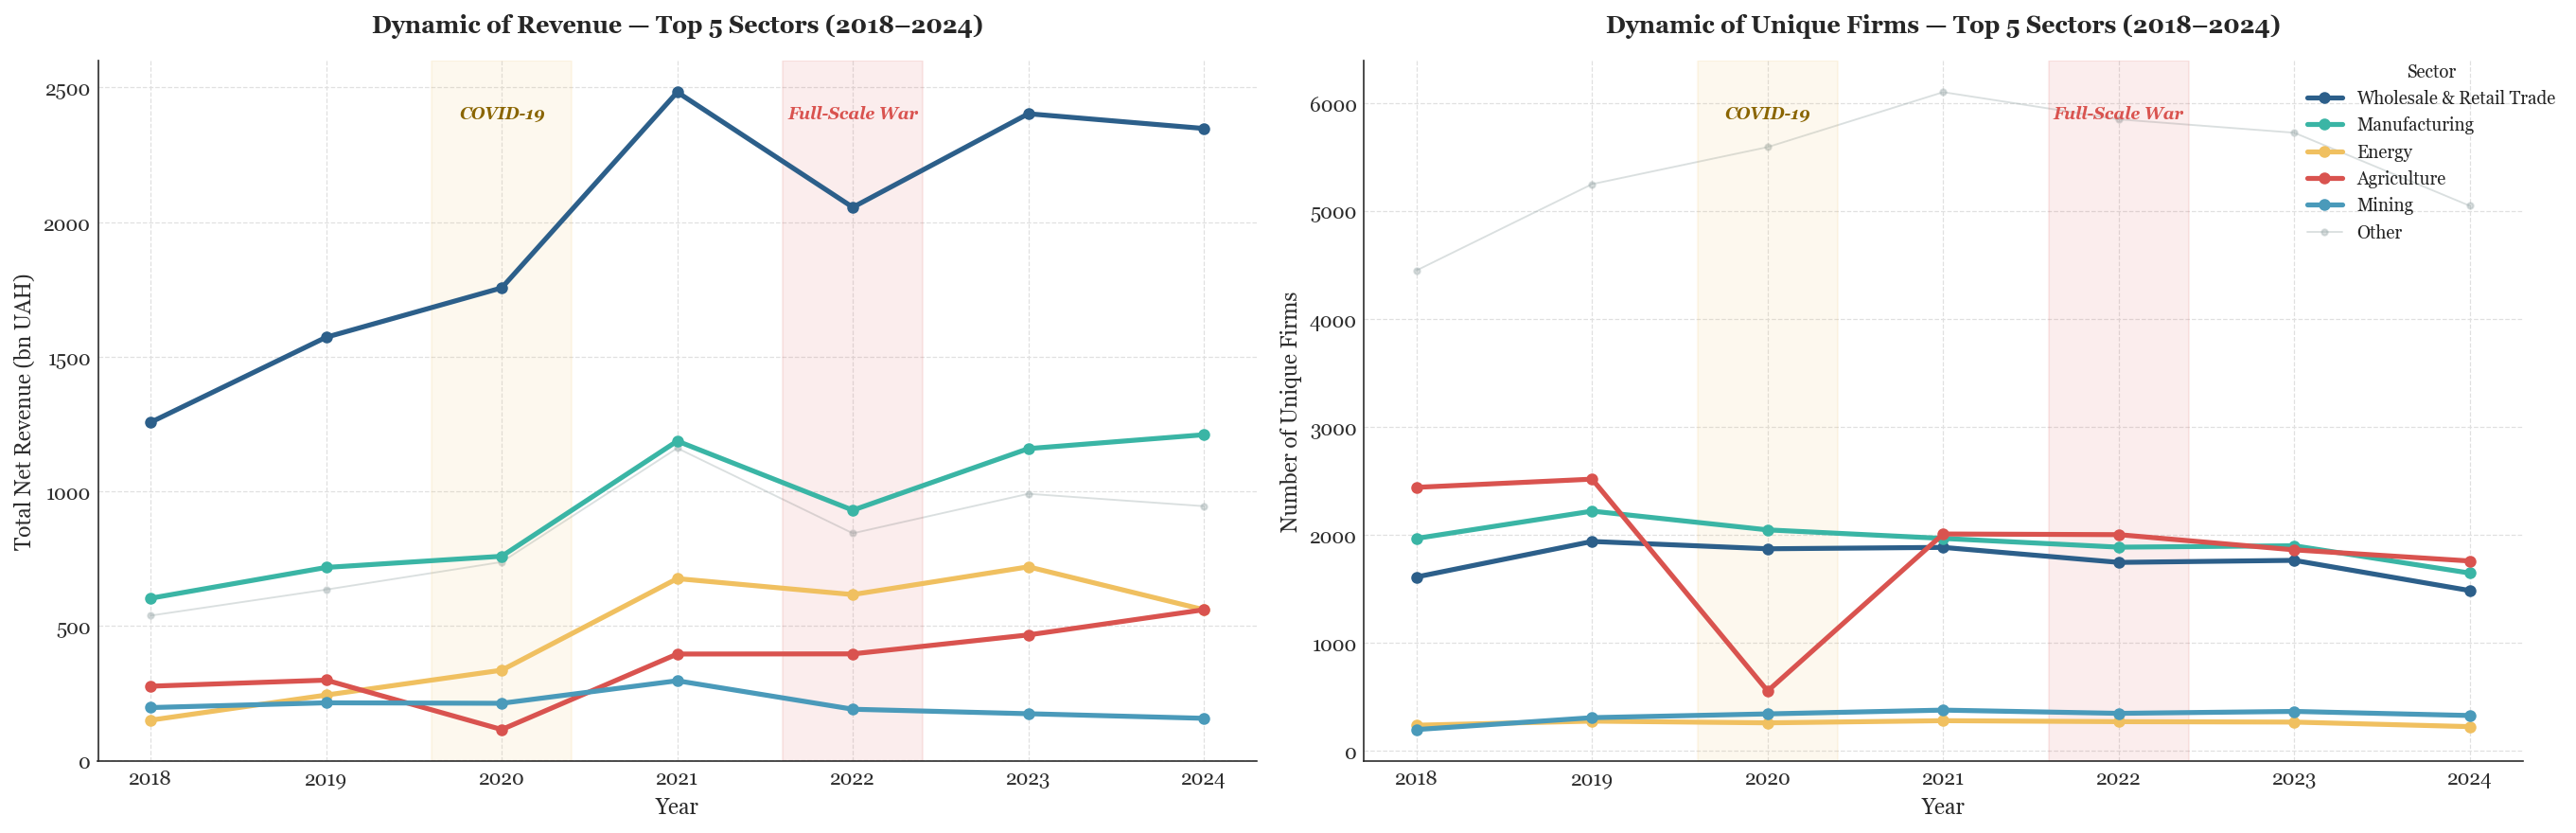

In [18]:
# Helper: plot top-5 sector lines on two axes with a shared legend
def plot_sector_lines(ax0_data, ax1_data, y_col_0, y_col_1,
                      y_label_0, y_label_1, title_0, title_1,
                      other_0, other_1, filename):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    for ax, data, other, y_col, y_label, title in zip(
        axes,
        [ax0_data, ax1_data],
        [other_0,  other_1],
        [y_col_0,  y_col_1],
        [y_label_0, y_label_1],
        [title_0,  title_1],
    ):
        ax.plot(other['Year'], other[y_col],
                marker='o', markersize=3,
                color=COLORS['neutral'], linewidth=0.9,
                alpha=0.35, zorder=2, label='Other')

        for sector in TOP5_SECTORS:
            group = data[data['Sector Label'] == sector]
            ax.plot(group['Year'], group[y_col],
                    marker='o', markersize=5,
                    color=TOP5_COLORS[sector], linewidth=2.5,
                    alpha=1.0, zorder=5, label=sector)

        y_max = max(data[data['Sector Label'].isin(TOP5_SECTORS)][y_col].max(),
                    other[y_col].max())
        add_crisis_bands(ax, y_max)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Year')
        ax.set_ylabel(y_label)
        ax.set_xticks(YEARS)

    handles, labels = axes[0].get_legend_handles_labels()
    top5_hl  = [(h, l) for h, l in zip(handles, labels) if l != 'Other']
    other_hl = [(h, l) for h, l in zip(handles, labels) if l == 'Other']
    sh, sl   = zip(*top5_hl + other_hl)
    fig.legend(sh, sl, loc='center right', bbox_to_anchor=(1.01, 0.81),
               fontsize=9, title='Sector', title_fontsize=9)

    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()


# Absolute values chart
rev_abs = revenue_by_sector_year.copy()
rev_abs['Total Net Revenue (bn UAH)'] = rev_abs['Total Net Revenue'] / 1_000_000
rev_other_abs = revenue_other.copy()
rev_other_abs['Total Net Revenue (bn UAH)'] = rev_other_abs['Total Net Revenue'] / 1_000_000

firms_abs = firms_by_sector_year.copy()
firms_other_abs = firms_other.copy()

plot_sector_lines(
    ax0_data=rev_abs,
    ax1_data=firms_abs,
    y_col_0='Total Net Revenue (bn UAH)',
    y_col_1='Unique Firms',
    y_label_0='Total Net Revenue (bn UAH)',
    y_label_1='Number of Unique Firms',
    title_0='Dynamic of Revenue — Top 5 Sectors (2018–2024)',
    title_1='Dynamic of Unique Firms — Top 5 Sectors (2018–2024)',
    other_0=rev_other_abs,
    other_1=firms_other_abs,
    filename='sector_revenue_firms_lines_abs.png'
)

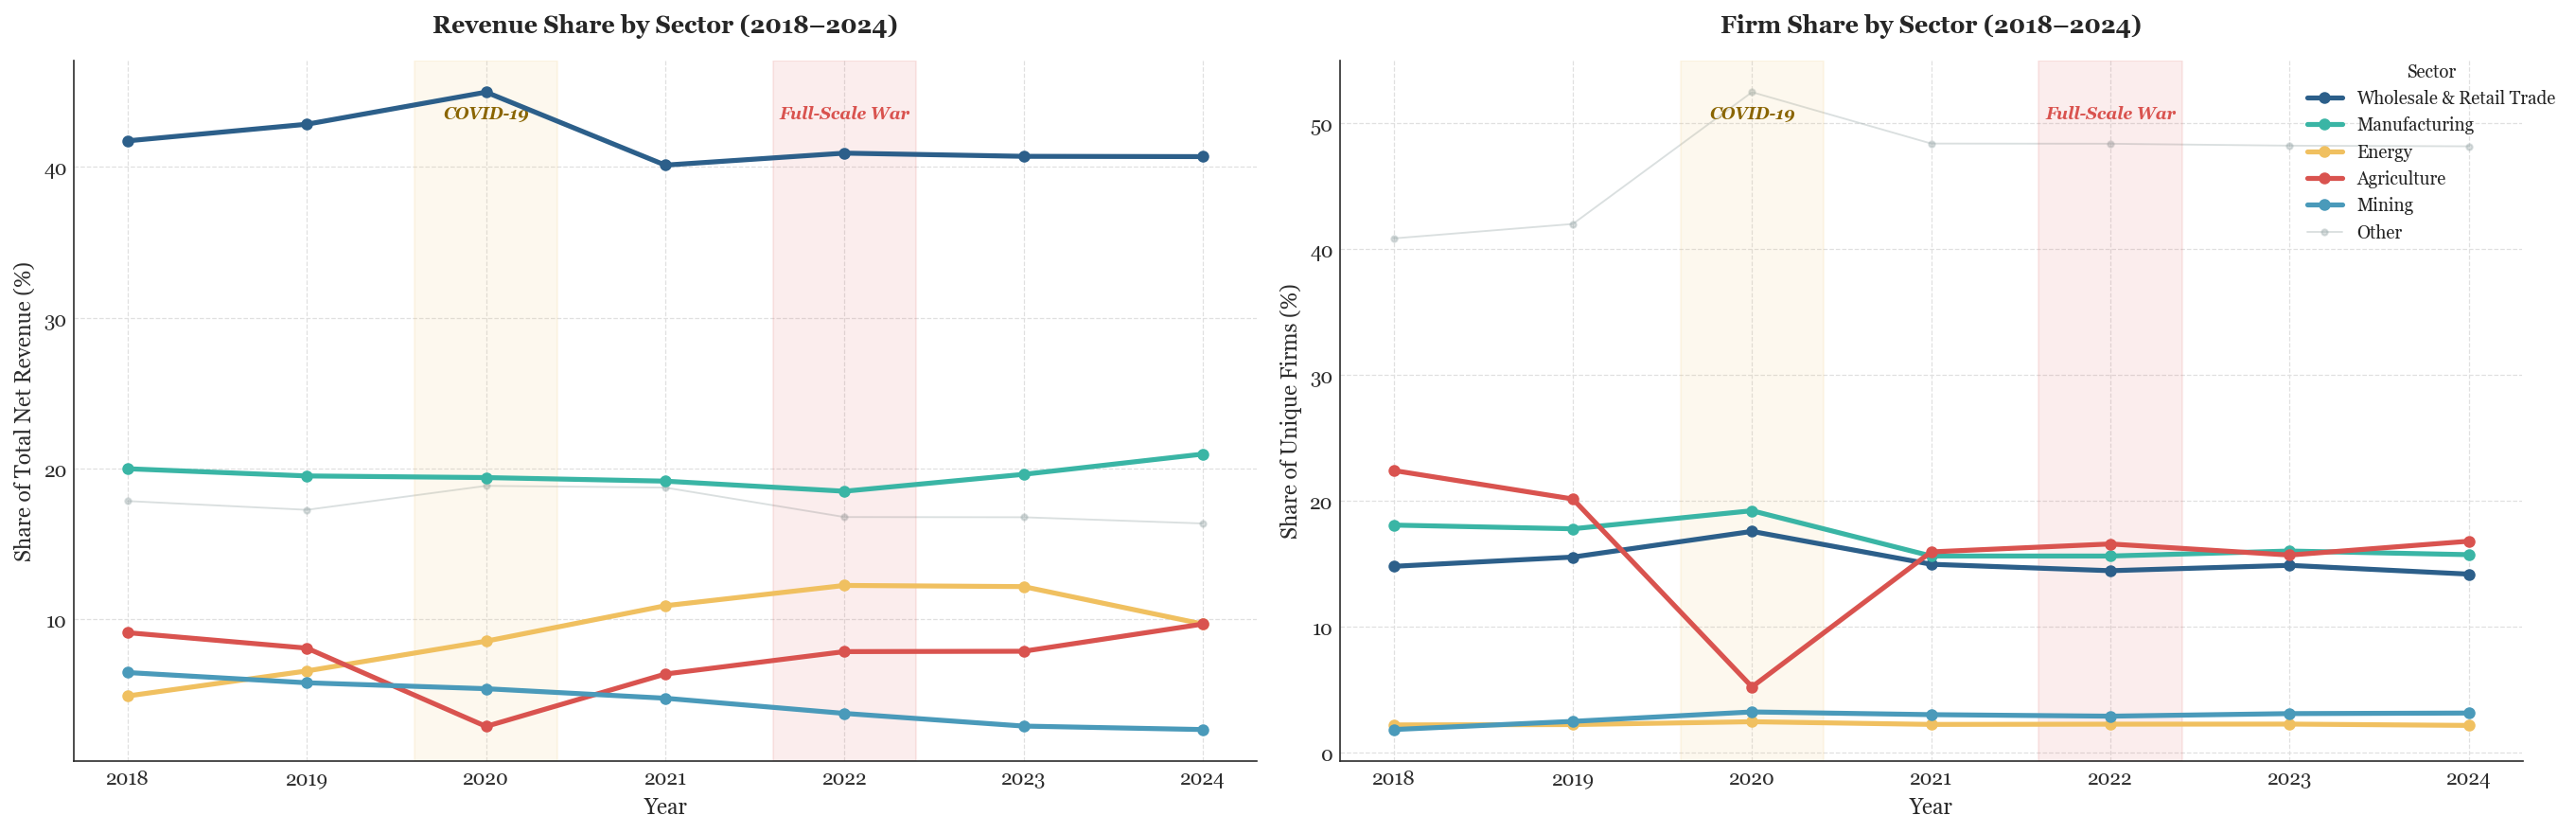

Revenue Share (%) by Sector and Year:
Year                      2018  2019  2020  2021  2022  2023  2024
Sector Label                                                      
Wholesale & Retail Trade  41.7  42.8  45.0  40.1  40.9  40.7  40.7
Manufacturing             20.0  19.5  19.4  19.2  18.5  19.6  20.9
Energy                     4.9   6.6   8.5  10.9  12.2  12.2   9.7
Agriculture                9.1   8.1   2.9   6.4   7.8   7.9   9.7
Mining                     6.5   5.8   5.4   4.7   3.7   2.9   2.7
Other                     17.8  17.3  18.8  18.7  16.8  16.8  16.3

Firms Share (%) by Sector and Year:
Year                      2018  2019  2020  2021  2022  2023  2024
Sector Label                                                      
Wholesale & Retail Trade  14.8  15.5  17.5  14.9  14.4  14.8  14.1
Manufacturing             18.0  17.8  19.2  15.6  15.6  16.0  15.7
Energy                     2.2   2.2   2.4   2.2   2.2   2.2   2.1
Agriculture               22.4  20.1   5.2  15.9  16.5

In [19]:
# Share chart + pivot summary tables
plot_sector_lines(
    ax0_data=revenue_by_sector_year,
    ax1_data=firms_by_sector_year,
    y_col_0='Revenue Share (%)',
    y_col_1='Firms Share (%)',
    y_label_0='Share of Total Net Revenue (%)',
    y_label_1='Share of Unique Firms (%)',
    title_0='Revenue Share by Sector (2018–2024)',
    title_1='Firm Share by Sector (2018–2024)',
    other_0=revenue_other,
    other_1=firms_other,
    filename='sector_revenue_firms_lines_share.png'
)

# Summary pivot tables
all_sectors = TOP5_SECTORS + ['Other']

rev_all = pd.concat([
    revenue_by_sector_year[revenue_by_sector_year['Sector Label'].isin(TOP5_SECTORS)],
    revenue_other
])
firms_all = pd.concat([
    firms_by_sector_year[firms_by_sector_year['Sector Label'].isin(TOP5_SECTORS)],
    firms_other
])

rev_pivot   = rev_all.pivot(index='Sector Label', columns='Year', values='Revenue Share (%)').round(1).reindex(all_sectors)
firms_pivot = firms_all.pivot(index='Sector Label', columns='Year', values='Firms Share (%)').round(1).reindex(all_sectors)

print('Revenue Share (%) by Sector and Year:')

print(rev_pivot.to_string())

print('\nFirms Share (%) by Sector and Year:')

print(firms_pivot.to_string())

In [20]:
# Detailed summary: revenue and firms for top-5 sectors
print('\nSECTOR SUMMARY: REVENUE AND FIRMS SHARE')
print(sector_data[['Sector Label', 'Unique Firms', 'Firms Share (%)', 'Revenue Share (%)']]
      .to_string(index=False))

print('\nTOP 5 SECTORS — TOTAL NET REVENUE (bn UAH) BY YEAR')
rev_abs_pivot = (
    revenue_by_sector_year[revenue_by_sector_year['Sector Label'].isin(TOP5_SECTORS)]
    .pivot(index='Sector Label', columns='Year', values='Total Net Revenue')
    .div(1_000_000).round(1)
)
print(rev_abs_pivot.to_string())

print('\nTOP 5 SECTORS — UNIQUE FIRMS BY YEAR')
firms_abs_pivot = (
    firms_by_sector_year[firms_by_sector_year['Sector Label'].isin(TOP5_SECTORS)]
    .pivot(index='Sector Label', columns='Year', values='Unique Firms')
)
print(firms_abs_pivot.to_string())


SECTOR SUMMARY: REVENUE AND FIRMS SHARE
               Sector Label  Unique Firms  Firms Share (%)  Revenue Share (%)
   Wholesale & Retail Trade          2901             16.0               41.5
              Manufacturing          2957             16.3               19.6
                     Energy           442              2.4                9.8
                Agriculture          2854             15.8                7.4
                     Mining           476              2.6                4.3
             Transportation           735              4.1                3.4
      Professional Services           754              4.2                2.4
               Construction           754              4.2                2.2
Information & Communication           369              2.0                1.9
                  Education           162              0.9                1.8
         Financial Services          2925             16.1                1.5
       Health & Social 

## 7. Regional analysis

Summarising firms and revenue by region, identifying the top sector and top KVED per region by cumulative revenue.

In [21]:
region_summary = df.groupby('Region').agg(
    Unique_Firms   = ('Firm ID',     'nunique'),
    Total_Revenue  = ('Net Revenue', 'sum'),
    Median_Revenue = ('Net Revenue', 'median'),
).reset_index()

region_summary['Total Revenue (bn UAH)']  = (region_summary['Total_Revenue']  / 1_000_000).round(1)
region_summary['Median Revenue (k UAH)']  = (region_summary['Median_Revenue'] / 1_000).round(1)
region_summary['Share of Firms (%)']      = (
    region_summary['Unique_Firms'] / region_summary['Unique_Firms'].sum() * 100
).round(1)
region_summary = region_summary.sort_values('Total Revenue (bn UAH)', ascending=False)

print('Regional Summary — Firms and Revenue:')
print(region_summary[['Region', 'Unique_Firms', 'Share of Firms (%)',
                       'Total Revenue (bn UAH)', 'Median Revenue (k UAH)']]
      .to_string(index=False))

Regional Summary — Firms and Revenue:
                   Region  Unique_Firms  Share of Firms (%)  Total Revenue (bn UAH)  Median Revenue (k UAH)
                  м. Київ          5407                29.8                 13287.4                    10.8
 Дніпропетровська область          1474                 8.1                  4715.4                    49.6
         Київська область           978                 5.4                  2329.0                    61.2
        Львівська область          1058                 5.8                  1569.4                    31.3
       Харківська область          1137                 6.3                  1353.9                    48.8
          Одеська область           845                 4.7                  1056.0                    40.1
       Полтавська область           628                 3.5                  1016.2                    67.2
        Черкаська область           519                 2.9                   903.5               

In [22]:
# Top sector per region by cumulative revenue
top_sector_region = (
    df.groupby(['Region', 'Sector'])['Net Revenue'].sum()
    .reset_index().rename(columns={'Net Revenue': 'Sector Revenue'})
)
top_sector_region['Sector Label'] = top_sector_region['Sector'].map(SECTOR_MAP)
top_sector_region = (
    top_sector_region.sort_values('Sector Revenue', ascending=False)
    .groupby('Region').first().reset_index()
    [['Region', 'Sector Label', 'Sector Revenue']]
)
top_sector_region['Sector Revenue (bn UAH)'] = (top_sector_region['Sector Revenue'] / 1_000_000).round(1)

# Top KVED per region by cumulative revenue
top_kved_region = (
    df.groupby(['Region', 'KVED'])['Net Revenue'].sum()
    .reset_index().rename(columns={'Net Revenue': 'KVED Revenue'})
)
top_kved_region = (
    top_kved_region.sort_values('KVED Revenue', ascending=False)
    .groupby('Region').first().reset_index()
    [['Region', 'KVED', 'KVED Revenue']]
)
top_kved_region['KVED Revenue (bn UAH)'] = (top_kved_region['KVED Revenue'] / 1_000_000).round(1)

region_full = (
    region_summary[['Region', 'Unique_Firms', 'Total Revenue (bn UAH)']]
    .merge(top_sector_region[['Region', 'Sector Label', 'Sector Revenue (bn UAH)']], on='Region')
    .merge(top_kved_region[['Region', 'KVED', 'KVED Revenue (bn UAH)']], on='Region')
    .sort_values('Total Revenue (bn UAH)', ascending=False)
)

print('\nTop Sector and KVED by Revenue per Region:')
print(region_full.to_string(index=False))


Top Sector and KVED by Revenue per Region:
                   Region  Unique_Firms  Total Revenue (bn UAH)             Sector Label  Sector Revenue (bn UAH)  KVED  KVED Revenue (bn UAH)
                  м. Київ          5407                 13287.4 Wholesale & Retail Trade                   6856.6 35.14                 1246.6
 Дніпропетровська область          1474                  4715.4 Wholesale & Retail Trade                   1978.6 47.11                  728.2
         Київська область           978                  2329.0 Wholesale & Retail Trade                   1100.4 46.32                  301.8
        Львівська область          1058                  1569.4 Wholesale & Retail Trade                    733.0 46.71                  249.2
       Харківська область          1137                  1353.9 Wholesale & Retail Trade                    547.9 64.30                  106.0
          Одеська область           845                  1056.0 Wholesale & Retail Trade          

## 8. Frontline region analysis

Classifying regions into three groups (conflict since 2014, frontline from 2022, non-frontline), then comparing revenue dynamics and computing the 2021→2022 revenue drop for the newly affected zone.

In [23]:
def classify_region(region):
    if region in FRONTLINE_2014:
        return 'Conflict since 2014'
    elif region in FRONTLINE_2022:
        return 'Frontline from 2022'
    else:
        return 'Non-frontline'

df['Region Type'] = df['Region'].apply(classify_region)

print('Region classification:')
print(df.groupby('Region Type')['Firm ID'].nunique()
        .reset_index().rename(columns={'Firm ID': 'Unique Firms'})
        .to_string(index=False))

Region classification:
        Region Type  Unique Firms
Conflict since 2014           532
Frontline from 2022          3045
      Non-frontline         14542


In [24]:
# Frontline aggregates by zone and year
frontline_all = FRONTLINE_2014 + FRONTLINE_2022

zone_year = df[df['Region'].isin(frontline_all)].copy()
zone_year['Zone'] = zone_year['Region'].apply(
    lambda r: 'Conflict since 2014' if r in FRONTLINE_2014 else 'Frontline from 2022'
)

zone_agg = (
    zone_year.groupby(['Year', 'Zone'])['Net Revenue'].sum()
    .reset_index()
)
zone_agg['Year']                   = zone_agg['Year'].astype(int)
zone_agg['Total Revenue (bn UAH)'] = (zone_agg['Net Revenue'] / 1_000_000).round(1)

# Revenue drop 2021→2022 for the newly affected zone
zone_2022  = zone_agg[zone_agg['Zone'] == 'Frontline from 2022']
rev_2021   = zone_2022[zone_2022['Year'] == 2021]['Total Revenue (bn UAH)'].values[0]
rev_2022   = zone_2022[zone_2022['Year'] == 2022]['Total Revenue (bn UAH)'].values[0]
pct_drop   = ((rev_2022 - rev_2021) / rev_2021 * 100).round(1)

# Kyiv City and Other regions
kyiv_year = (
    df[df['Region'] == 'м. Київ']
    .groupby('Year')['Net Revenue'].sum().reset_index()
)
kyiv_year['Year']                   = kyiv_year['Year'].astype(int)
kyiv_year['Total Revenue (bn UAH)'] = (kyiv_year['Net Revenue'] / 1_000_000).round(1)
kyiv_year['Zone']                   = 'Kyiv City'

other_regions = [r for r in df['Region'].unique()
                 if r not in frontline_all and r != 'м. Київ']
other_year = (
    df[df['Region'].isin(other_regions)]
    .groupby('Year')['Net Revenue'].sum().reset_index()
)
other_year['Year']                   = other_year['Year'].astype(int)
other_year['Total Revenue (bn UAH)'] = (other_year['Net Revenue'] / 1_000_000).round(1)
other_year['Zone']                   = 'Other Regions'

zone_agg_full = pd.concat([
    zone_agg[['Year', 'Zone', 'Total Revenue (bn UAH)']],
    kyiv_year[['Year', 'Zone', 'Total Revenue (bn UAH)']],
    other_year[['Year', 'Zone', 'Total Revenue (bn UAH)']],
], ignore_index=True)

print(f'Revenue drop 2021→2022 (Frontline from 2022): {pct_drop}%')

pivot_firms = (
    df[df['Region'].isin(frontline_all)]
    .assign(Zone=lambda d: d['Region'].apply(
        lambda r: 'Conflict since 2014' if r in FRONTLINE_2014 else 'Frontline from 2022'
    ))
    .groupby(['Year', 'Zone'])['Firm ID'].nunique()
    .reset_index()
    .pivot(index='Year', columns='Zone', values='Firm ID')
)
print('\nUnique Firms by Frontline Zone:')
print(pivot_firms.to_string())

Revenue drop 2021→2022 (Frontline from 2022): -34.1%

Unique Firms by Frontline Zone:
Zone    Conflict since 2014  Frontline from 2022
Year                                            
2018.0                  401                 2109
2019.0                  447                 2346
2020.0                  315                 1721
2021.0                  241                 1960
2022.0                  158                 1797
2023.0                  147                 1737
2024.0                  125                 1533


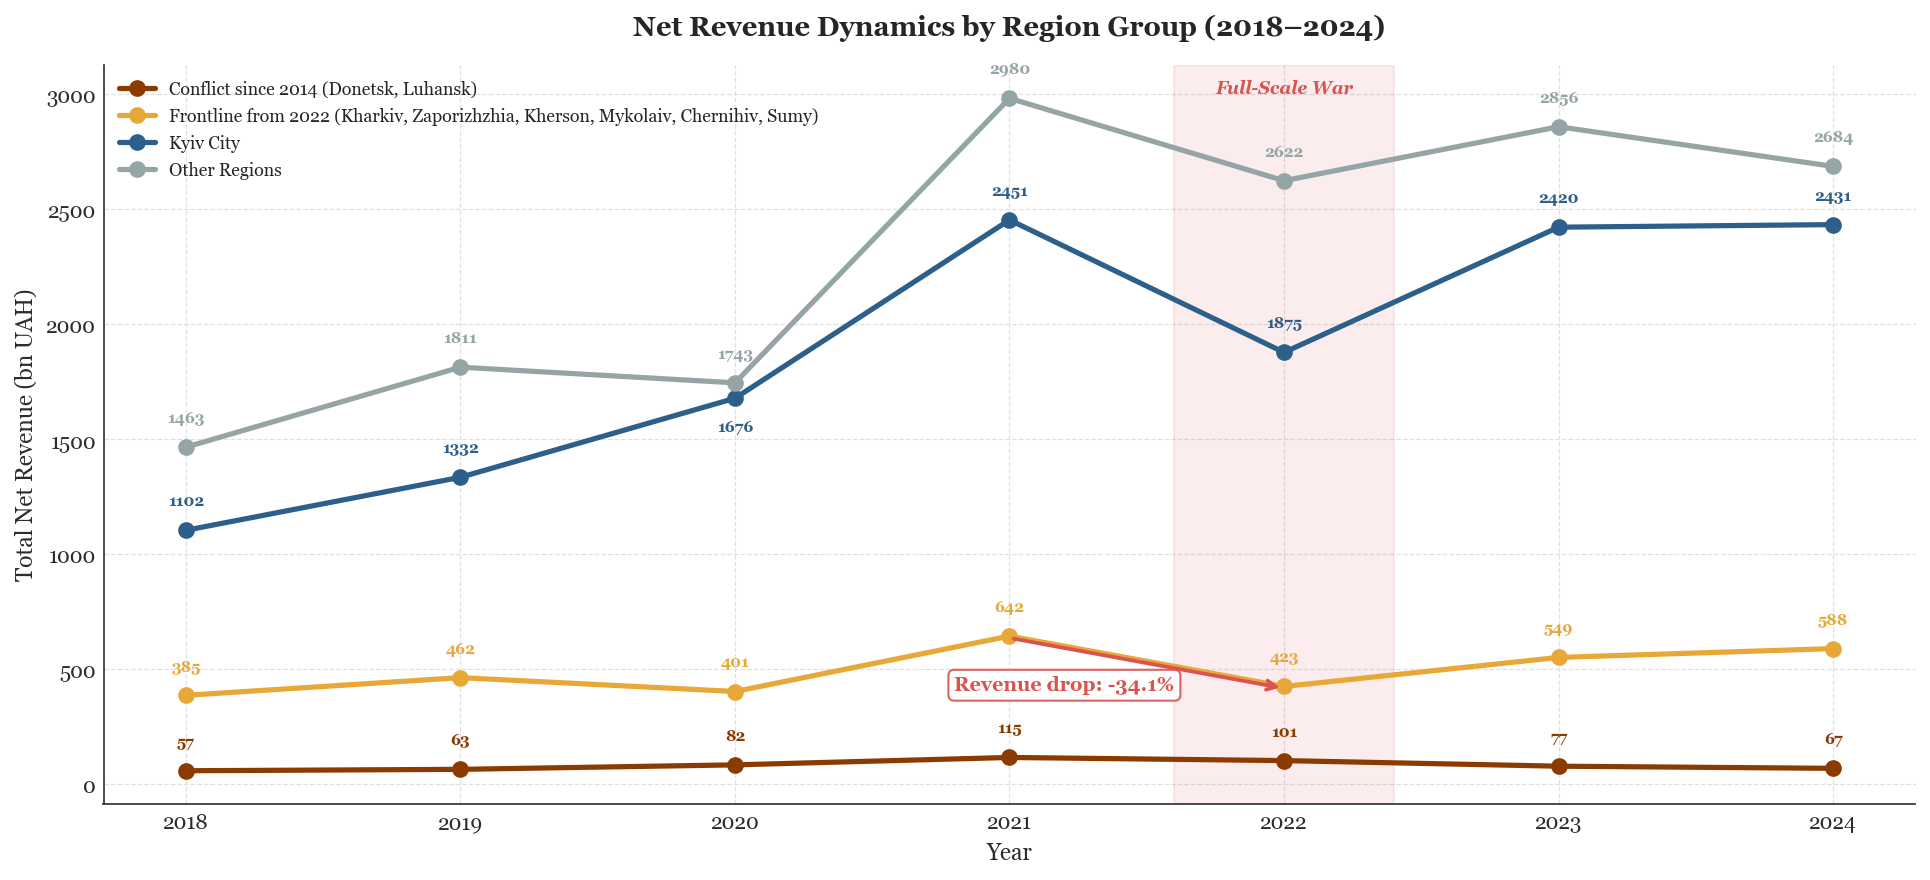

In [25]:
# Line chart: revenue dynamics for all zone groups
zone_colors = {
    'Conflict since 2014': '#8B3A00',
    'Frontline from 2022': '#E8A838',
    'Kyiv City':           COLORS['primary'],
    'Other Regions':       COLORS['neutral'],
}
zone_legend = {
    'Conflict since 2014': 'Conflict since 2014 (Donetsk, Luhansk)',
    'Frontline from 2022': 'Frontline from 2022 (Kharkiv, Zaporizhzhia, Kherson, Mykolaiv, Chernihiv, Sumy)',
    'Kyiv City':           'Kyiv City',
    'Other Regions':       'Other Regions',
}
label_below = {'Kyiv City': [2020]}

fig, ax = plt.subplots(figsize=(13, 6))

for zone, group in zone_agg_full.groupby('Zone'):
    group = group.sort_values('Year')
    ax.plot(group['Year'], group['Total Revenue (bn UAH)'],
            marker='o', markersize=7,
            color=zone_colors[zone], linewidth=2.5,
            label=zone_legend[zone], zorder=5)

ylim_top = ax.get_ylim()[1]

for zone, group in zone_agg_full.groupby('Zone'):
    group = group.sort_values('Year')
    for _, row in group.iterrows():
        below  = row['Year'] in label_below.get(zone, [])
        sign   = -1 if below else +1
        va     = 'top' if below else 'bottom'
        ax.text(row['Year'],
                row['Total Revenue (bn UAH)'] + sign * ylim_top * 0.03,
                f"{row['Total Revenue (bn UAH)']:.0f}",
                ha='center', fontsize=7.5,
                color=zone_colors[zone], fontweight='bold', va=va)

# Revenue drop bracket
offset = -8
ax.annotate('',
            xy=(2022, rev_2022 + offset), xytext=(2021, rev_2021 + offset),
            arrowprops=dict(arrowstyle='->', color=COLORS['negative'], lw=1.8), zorder=6)
for year, rev in [(2021, rev_2021), (2022, rev_2022)]:
    ax.plot([year, year], [rev + offset, rev],
            color=COLORS['negative'], linewidth=0.8, linestyle=':', alpha=0.6, zorder=4)
ax.text(2021.2, (rev_2021 + rev_2022) / 2 + offset - 120,
        f'Revenue drop: {pct_drop:.1f}%',
        ha='center', fontsize=9.5, color=COLORS['negative'], fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=COLORS['negative'], alpha=0.9))

ax.axvspan(2021.6, 2022.4, alpha=0.10, color=COLORS['negative'], zorder=2)
ax.text(2022, ax.get_ylim()[1] * 0.98, 'Full-Scale War',
        ha='center', fontsize=8.5, color=COLORS['negative'],
        fontweight='bold', style='italic', va='top')

ax.set_title('Net Revenue Dynamics by Region Group (2018–2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Net Revenue (bn UAH)')
ax.set_xticks(YEARS)
ax.legend(fontsize=8.5, loc='upper left')

plt.tight_layout()
plt.savefig('frontline_aggregated_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Top sector and cumulative revenue per frontline region
region_total_front = (
    df[df['Region'].isin(frontline_all)]
    .groupby('Region')['Net Revenue'].sum()
    .div(1_000_000).round(1).to_dict()
)

top_sector_frontline = {}
for region in frontline_all:
    region_data     = df[df['Region'] == region]
    sector_rev      = region_data.groupby('Sector')['Net Revenue'].sum().sort_values(ascending=False)
    top_sector_code = sector_rev.index[0]
    top_sector_pct  = (sector_rev.iloc[0] / sector_rev.sum() * 100).round(0)
    top_sector_frontline[region] = (SECTOR_MAP.get(top_sector_code, top_sector_code), int(top_sector_pct))

# YoY revenue change per region 2021→2022
region_year_rev = (
    df.groupby(['Region', 'Year'])['Net Revenue'].sum()
    .reset_index().rename(columns={'Net Revenue': 'Revenue'})
)
region_year_rev['Year'] = region_year_rev['Year'].astype(int)

frontline_2014_sorted = sorted(FRONTLINE_2014, key=lambda r: region_total_front.get(r, 0), reverse=True)
frontline_2022_sorted = sorted(FRONTLINE_2022, key=lambda r: region_total_front.get(r, 0), reverse=True)

frontline_table = []
for region in frontline_2014_sorted + frontline_2022_sorted:
    sector_name, sector_pct = top_sector_frontline[region]

    r_2021 = region_year_rev[
        (region_year_rev['Region'] == region) & (region_year_rev['Year'] == 2021)
    ]['Revenue'].sum() / 1_000_000
    r_2022 = region_year_rev[
        (region_year_rev['Region'] == region) & (region_year_rev['Year'] == 2022)
    ]['Revenue'].sum() / 1_000_000

    yoy = round((r_2022 - r_2021) / r_2021 * 100, 1) if r_2021 > 0 else None

    frontline_table.append({
        'Region'                : REGION_UA_TO_EN.get(region, region),
        'Conflict Phase'        : 'Since 2014' if region in FRONTLINE_2014 else 'From 2022',
        'Total Revenue (bn UAH)': region_total_front.get(region, 0),
        'Top Sector'            : sector_name,
        'Top Sector Share (%)'  : sector_pct,
        'Revenue 2021 (bn UAH)' : round(r_2021, 1),
        'Revenue 2022 (bn UAH)' : round(r_2022, 1),
        'Change 2021→2022 (%)'  : yoy,
    })

frontline_df = pd.DataFrame(frontline_table)
print('Frontline Regions — Revenue and Sector Summary')
print(frontline_df.to_string(index=False))

Frontline Regions — Revenue and Sector Summary
             Region Conflict Phase  Total Revenue (bn UAH)               Top Sector  Top Sector Share (%)  Revenue 2021 (bn UAH)  Revenue 2022 (bn UAH)  Change 2021→2022 (%)
     Donetsk Oblast     Since 2014                   509.9                   Mining                    48                  108.5                   99.8                  -8.0
     Luhansk Oblast     Since 2014                    51.8     Health & Social Work                    52                    6.1                    1.1                 -81.4
     Kharkiv Oblast      From 2022                  1353.9 Wholesale & Retail Trade                    40                  234.9                  176.4                 -24.9
Zaporizhzhia Oblast      From 2022                   735.4            Manufacturing                    43                  138.7                   78.4                 -43.4
    Mykolaiv Oblast      From 2022                   513.0 Wholesale & Retail Trade

## 9. Choropleth map — revenue share by region

Loading the GADM Ukraine shapefile and mapping cumulative 2018–2024 revenue share to a log-scaled choropleth. Crimea and Sevastopol are shaded grey (not in the dataset).

In [27]:
ukraine = gpd.read_file(
    'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_UKR_1.json'
)
print('Shapefile regions:', ukraine['NAME_1'].unique())

Shapefile regions: ['?' 'Cherkasy' 'Chernihiv' 'Chernivtsi' 'Crimea' "Dnipropetrovs'k"
 "Donets'k" "Ivano-Frankivs'k" 'Kharkiv' 'Kherson' "Khmel'nyts'kyy" 'Kiev'
 'KievCity' 'Kirovohrad' "L'viv" "Luhans'k" 'Mykolayiv' 'Odessa' 'Poltava'
 'Rivne' "Sevastopol'" 'Sumy' "Ternopil'" 'Vinnytsya' 'Volyn'
 'Zakarpattia' 'Zaporizhia' 'Zhytomyr']


In [28]:
# Prepare region revenue data and merge with shapefile
region_map_data = (
    df.groupby('Region')['Net Revenue'].sum()
    .div(1_000_000).round(1)
    .reset_index()
    .rename(columns={'Net Revenue': 'Total Revenue (bn UAH)'})
)
region_map_data['Region EN'] = region_map_data['Region'].map(REGION_SHAPEFILE_MAP)

ukraine_map = ukraine.merge(
    region_map_data[['Region EN', 'Total Revenue (bn UAH)']],
    left_on='NAME_1', right_on='Region EN', how='left'
)

total = ukraine_map['Total Revenue (bn UAH)'].sum()
ukraine_map['Revenue Share (%)'] = (ukraine_map['Total Revenue (bn UAH)'] / total * 100).round(1)

unmatched = ukraine_map[ukraine_map['Total Revenue (bn UAH)'].isna()]['NAME_1'].values
print('Unmatched regions:', unmatched)
print('Matched regions  :', ukraine_map['Total Revenue (bn UAH)'].notna().sum())

Unmatched regions: ['?' 'Crimea' "Sevastopol'"]
Matched regions  : 25


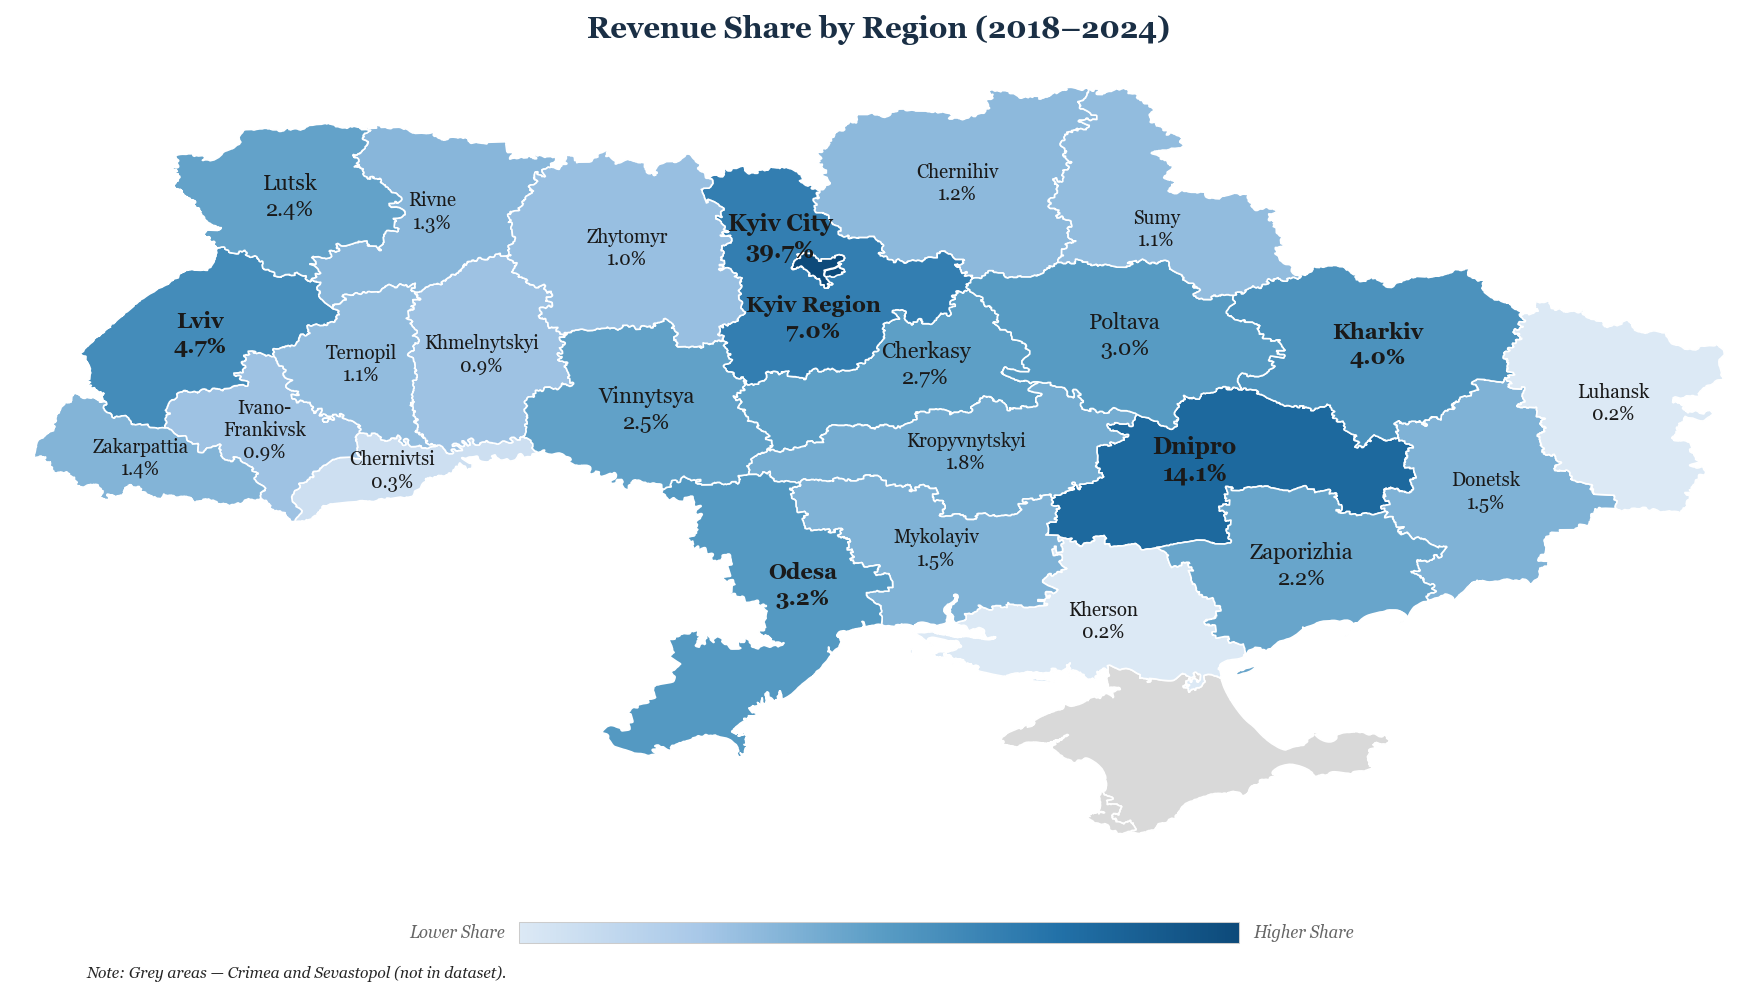

In [29]:
# Choropleth
cmap = LinearSegmentedColormap.from_list(
    'ukraine_blue', ['#dce9f5', '#a8c8e8', '#5a9dc5', '#2271a8', '#0d4a7a']
)
vmin = ukraine_map['Revenue Share (%)'].dropna()
vmin = vmin[vmin > 0].min()
vmax = ukraine_map['Revenue Share (%)'].max()
norm = LogNorm(vmin=vmin, vmax=vmax)

label_offsets = {
    'KievCity':         (-0.4,  0.3),
    'Kiev':             (0,    -0.4),
    'Odessa':           (0.5,   0.3),
    'Sumy':             (0,    -0.25),
    "Dnipropetrovs'k":  (-0.3,  0.1),
    'Cherkasy':         (0.3,   0.15),
}
name_map = {
    'KievCity':          'Kyiv City',     'Kiev':               'Kyiv Region',
    "Dnipropetrovs'k":   'Dnipro',        "Donets'k":           'Donetsk',
    "Ivano-Frankivs'k":  'Ivano-\nFrankivsk',
    "Khmel'nyts'kyy":    'Khmelnytskyi',  "L'viv":              'Lviv',
    "Luhans'k":          'Luhansk',       "Ternopil'":          'Ternopil',
    'Odessa':            'Odesa',         'Volyn':              'Lutsk',
    'Kirovohrad':        'Kropyvnytskyi',
}

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')

# Grey fill for Crimea and Sevastopol
ukraine_map[ukraine_map['NAME_1'].isin(['Crimea', "Sevastopol'"])].plot(
    ax=ax, color='#d9d9d9', edgecolor='white', linewidth=0.8
)
# Kyiv City district (shapefile artefact '?') — same colour as Kyiv City
kyiv_share = ukraine_map[ukraine_map['NAME_1'] == 'KievCity']['Revenue Share (%)'].values[0]
ukraine_map[ukraine_map['NAME_1'] == '?'].plot(
    ax=ax, color=cmap(norm(kyiv_share)), edgecolor='white', linewidth=0.8
)
# All regions with data
ukraine_map[ukraine_map['Revenue Share (%)'].notna()].plot(
    ax=ax, column='Revenue Share (%)', cmap=cmap, norm=norm,
    edgecolor='white', linewidth=0.8, legend=False
)

x_min, y_min, x_max, y_max = ukraine_map.total_bounds
ax.set_xlim(x_min - 0.2, x_max + 0.2)
ax.set_ylim(y_min - 0.3, y_max + 0.3)
ax.set_aspect('equal', adjustable='box')
ax.axis('off')

for _, row in ukraine_map.iterrows():
    if (pd.notna(row['Revenue Share (%)']) and
            row['Revenue Share (%)'] > 0 and
            row.geometry is not None and
            row['NAME_1'] != '?'):
        centroid   = row.geometry.centroid
        offset     = label_offsets.get(row['NAME_1'], (0, 0))
        name       = name_map.get(row['NAME_1'], row['NAME_1'])
        share      = row['Revenue Share (%)']
        fontsize   = 9.0 if share < 2 else 10.5 if share < 9 else 11.0
        fontweight = 'bold' if share > 3 else 'normal'
        ax.annotate(
            f"{name}\n{share:.1f}%",
            xy=(centroid.x + offset[0], centroid.y + offset[1]),
            ha='center', va='center',
            fontsize=fontsize, fontweight=fontweight, color='#1a1a1a'
        )

ax.set_title('Revenue Share by Region (2018–2024)',
             fontsize=14, fontweight='bold', pad=10, color='#1a2f45')

cax = fig.add_axes([0.30, 0.055, 0.40, 0.020])
cb  = ColorbarBase(cax, cmap=cmap, norm=norm, orientation='horizontal', ticks=[])
cb.outline.set_edgecolor('#cccccc')
cb.outline.set_linewidth(0.5)
cax.text(-0.02, 0.5, 'Lower Share', transform=cax.transAxes,
         ha='right', va='center', fontsize=8, color='#666666', style='italic')
cax.text(1.02, 0.5, 'Higher Share', transform=cax.transAxes,
         ha='left',  va='center', fontsize=8, color='#666666', style='italic')

fig.text(0.06, 0.022,
         'Note: Grey areas — Crimea and Sevastopol (not in dataset).',
         fontsize=7.5, style='italic')

plt.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.11)
plt.savefig('ukraine_revenue_map.png', dpi=150, bbox_inches='tight')
plt.show()